# Reproducing the multilingual antonym circuit on Qwen3-4b

Reproduces the **multilingual** dive of
[biology.html](https://transformer-circuits.pub/2025/attribution-graphs/biology.html).

The paper shows the antonym task — *the opposite of 'small' is* **big** (EN), *petit*->**grand** (FR),
*小*->**大** (ZH) — runs through a circuit with three parts: an **operand** (the concept *small*),
an **operation** (antonym vs synonym), and a **language** (detect input / emit in target language).
Operation & operand are **language-agnostic** (shared middle-layer features); the language parts
are language-specific (early input + late output). Each part is independently editable.

- **0.** Does Qwen3-4b do the antonym task in EN/FR/ZH?
- **A.** Per-language attribution graphs (small->big): operand / operation / language features.
- **B.** Cross-language feature-overlap by layer (the shared-middle signature).
- **C.** Interventions: operand swap (small->hot), operation swap (antonym->synonym), output-language swap.
- **D.** English as the mechanistic default (direct-effect asymmetry of shared 'say-big' features).

In [1]:
%matplotlib inline
import multilingual_helper as M, numpy as np, torch, matplotlib.pyplot as plt
from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder
from llm_circuits.settings import default_device, artifacts_dir
device = default_device()
model, tokenizer = load_qwen3('4b', dtype_str='bf16', device_map=device); model.eval()
tc = load_transcoder('qwen3-4b', device=device, dtype=torch.bfloat16, lazy_decoder=False).transcoder
OUT = artifacts_dir() / 'multilingual_notebook'; OUT.mkdir(parents=True, exist_ok=True)
LANGS = M.LANGS
print('loaded Qwen3-4b |', len(tc), 'layers')

[06/23/26 20:00:46] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/home/zw499/rds/hpc-work/llm-circuits/.cache/models)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[06/23/26 20:01:24] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/home/zw499/rds/hpc-work/llm-circuits/.cache/transcoders)

loaded Qwen3-4b | 36 layers


## 0. Does Qwen3-4b do the antonym task in EN/FR/ZH?

In [2]:
for concept in ['small', 'hot']:
    for lg in LANGS:
        tid, tstr, cont = M.model_answer(model, tokenizer, M.antonym_prompt(concept, lg))
        print(f'  {M.LANG_NAME[lg]:8} opposite of {M.WORD[concept][lg]!r:8} -> first={tstr!r:10}(id {tid})  cont={cont!r}')

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  English  opposite of 'small'  -> first='large'   (id 16767)  cont='large<|im_end|>'
  French   opposite of 'petit'  -> first='Grand'   (id 40151)  cont='Grand<|im_end|>'
  Chinese  opposite of '小'      -> first='大'       (id 26288)  cont='大<|im_end|>'


  English  opposite of 'hot'    -> first='cold'    (id 87072)  cont='cold<|im_end|>'
  French   opposite of 'chaud'  -> first='F'       (id 37)  cont='Froid<|im_end|>'
  Chinese  opposite of '热'      -> first='冷'       (id 99476)  cont='冷<|im_end|>'


## A. Per-language attribution graphs (small->big)
Each feature is tagged by position: **operand** (on the *small* token), **final** (predicting the
answer = where operation + output-language features sit), or another position. Explorers saved to
`artifacts/multilingual_notebook/`.

In [3]:
graphs, answers, ids = {}, {}, {}
for lg in LANGS:
    d, aid, iid = M.build_graph(model, tc, tokenizer, M.antonym_prompt('small', lg),
        out_html=str(OUT/f'graph_small_{lg}.html'), title=f'opposite of small ({lg})')
    graphs[lg], answers[lg], ids[lg] = d, aid, iid
    opos = M.operand_token_pos(tokenizer, iid, M.WORD['small'][lg]); last = iid.shape[1]-1
    print(f'\n=== {M.LANG_NAME[lg]}: answer={tokenizer.decode([aid])!r}  (operand token pos {opos}) ===')
    for f in M.answer_features(d, top_k=10):
        tag = 'operand' if f['position']==opos else ('final' if f['position']==last else f"pos{f['position']}")
        print(f"  [{tag:7}] {M.feature_label(f)}  infl={f.get('influence',0):.3f}")

[06/23/26 20:04:16] INFO     Selected 2 logits with cumulative probability 0.9922

/home/zw499/llm-circuits/src/llm_circuits/circuits/attribution_graph.py:476: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  prob=float(top_p[rank]),  # actual prob (influence seed; sums to ~desired_prob)


                    INFO     Built 9039 nodes (emb=29, feat=8000, err=1008, logit=2)

                    INFO     Pre-computing source contribution vectors ...

                    INFO       layer 0: 72 feature contributions computed

...

                    WARNING  Failed to load label for layer 34 feature 15971: No gzip magic found in feature blob  
                             at index 15971

                    WARNING  Failed to load label for layer 34 feature 28807: No gzip magic found in feature blob  
                             at index 28807

                    WARNING  Failed to load label for layer 35 feature 10607: No gzip magic found in feature blob  
                             at index 10607

                    WARNING  Failed to load label for layer 35 feature 123612: No gzip magic found in feature blob 
                             at index 123612


=== Chinese: answer='大'  (operand token pos 4) ===
  [final  ] L31 f11436 ( large/ small/ big)  infl=0.040
  [pos2   ] L0 f111640 ( Hal/ dest/sk)  infl=0.029
  [pos2   ] L0 f5196 (举/очно/lear)  infl=0.027
  [final  ] L30 f27666 (巨型/巨大的/巨大)  infl=0.026
  [pos1   ] L0 f17384 (未/重量/unde)  infl=0.026
  [final  ] L35 f10607  infl=0.025
  [final  ] L32 f100307 ( bigger/太大/大)  infl=0.024
  [final  ] L31 f104452 (更快/CAM/最快的)  infl=0.020
  [operand] L0 f133356 (wares/ sized/ intestine)  infl=0.018
  [final  ] L30 f25488 (isches/award/smarty)  infl=0.017


## B. Cross-language feature overlap by layer
For 20 parallel sentences (EN/FR/ZH) take the top-k features per layer and average the pairwise
IoU. The paper's signature: **low overlap at the ends** (language-specific tokenization/output),
**rising in the middle** (shared multilingual concepts).

> **Result (see plot):** only a weak match. A mid-network peak exists (layer 18/36), but overlap
> is also high at layers 0–1 and 35 — parallel sentences share surface tokens (quotes, punctuation),
> which the paper controls for with an **unrelated-prompt baseline** we don't compute here (TODO).
> Also `en-zh` is the *strongest* pair nearly everywhere — opposite to the paper's small model,
> plausibly reflecting Qwen3's EN+ZH-heavy training mix.

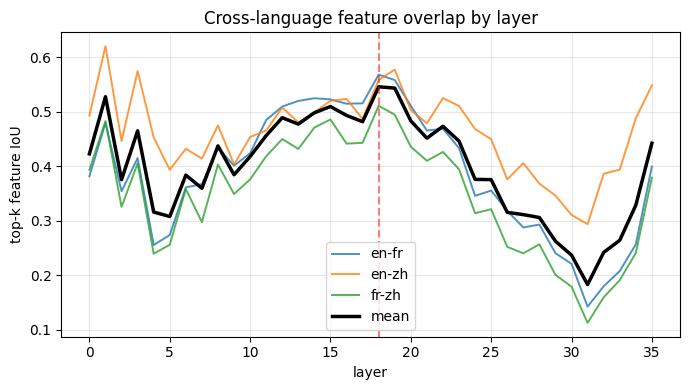

peak shared-overlap at layer 18 (IoU=0.55)
layer0 IoU=0.42  last IoU=0.44  middle-third mean=0.49


In [4]:
curves = M.overlap_curves(model, tc, tokenizer, k=64)
fig, ax = plt.subplots(figsize=(7,4)); M.plot_overlap_curves(curves, ax=ax)
peak = int(np.argmax(curves['mean'])); ax.axvline(peak, color='red', ls='--', alpha=0.5)
fig.tight_layout(); fig.savefig(OUT/'overlap_by_layer.png', dpi=130); plt.show()
m = curves['mean']; nl = len(m)
print(f'peak shared-overlap at layer {peak} (IoU={m.max():.2f})')
print(f'layer0 IoU={m[0]:.2f}  last IoU={m[-1]:.2f}  middle-third mean={m[nl//3:2*nl//3].mean():.2f}')

## C. Interventions (feature grafts via the m=-1/value steering API)
Each graft **ablates** the source supernode and **injects** a donor supernode (set to its donor
activation × scale) at the relevant position. Donor features are taken from the **English**
prompt and transferred into FR/ZH recipients — the paper's cross-lingual edit.

> **Protocol note:** the paper *negatively steers* the source supernode (−5× its activation,
> i.e. our `m=-6`), which is a much stronger suppression than the `m=-1` ablation used here.
> The milder suppression is a plausible cause of C2's partial result below (synonym direction
> appears but never becomes top-1) — worth re-running with `m=-6` on the source.

In [5]:
# C1. Operand swap: small -> hot. Donor/source = INFLUENCE-ranked operand features from the
# built graphs (the paper's criterion); top-activation at a position picks late generic
# features instead. Sweep injection scale.
SCALES = [1, 3, 6, 10]
hot_dict, _, hot_ids = M.build_graph(model, tc, tokenizer, M.antonym_prompt('hot','en'))
hot_pos = M.operand_token_pos(tokenizer, hot_ids, 'hot')
donor_hot = M.graph_features_at_position(hot_dict, hot_pos, top_n=10)
print(f'donor (EN hot @operand pos {hot_pos}, by influence) =', [(L,i) for L,i,_ in donor_hot], '\n')
for lg in LANGS:
    spos = M.operand_token_pos(tokenizer, ids[lg], M.WORD['small'][lg])
    source = M.graph_features_at_position(graphs[lg], spos, top_n=10)
    res = {sc: M.run_graft(model, tc, ids[lg], source, donor_hot, spos, scale=sc) for sc in SCALES}
    print(f'{M.LANG_NAME[lg]} small@{spos} ({len(source)} source feats)  baseline {M.top_token_probs(res[SCALES[0]].baseline_logits[-1], tokenizer)[:3]}')
    for sc in SCALES:
        print(f'   x{sc:<3}{M.top_token_probs(res[sc].ablated_logits[-1], tokenizer)[:4]}')

[06/23/26 20:08:26] INFO     Selected 1 logits with cumulative probability 0.9609

                    INFO     Built 9038 nodes (emb=29, feat=8000, err=1008, logit=1)

                    INFO     Pre-computing source contribution vectors ...

                    INFO       layer 0: 68 feature contributions computed

                    INFO       layer 1: 47 feature contributions computed

...

                    WARNING  Failed to load label for layer 35 feature 123612: No gzip magic found in feature blob 
                             at index 123612

donor (EN hot @operand pos 9, by influence) = [(24, 127078), (3, 131394), (3, 75392), (22, 85454), (5, 134029), (27, 143324), (8, 66332), (24, 8689), (7, 109065), (4, 85397)] 



English small@9 (10 source feats)  baseline [('large', 0.899), ('Large', 0.095), ('big', 0.005)]
   x1  [('cold', 0.953), ('Cold', 0.047), ('hot', 0.0), ('C', 0.0)]
   x3  [('cold', 0.88), ('Cold', 0.119), ('hot', 0.001), ('C', 0.0)]
   x6  [('cold', 0.939), ('Cold', 0.06), ('hot', 0.001), ('C', 0.0)]
   x10 [('cold', 0.939), ('Cold', 0.06), ('C', 0.001), ('c', 0.0)]


French small@12 (10 source feats)  baseline [('Grand', 0.816), ('grand', 0.182), ('Gr', 0.001)]
   x1  [('f', 0.992), ('F', 0.008), ('cha', 0.0), ('s', 0.0)]
   x3  [('f', 0.984), ('F', 0.016), ('fr', 0.0), ('_f', 0.0)]
   x6  [('f', 0.993), ('F', 0.005), ('fr', 0.001), ('gl', 0.0)]
   x10 [('f', 0.985), ('F', 0.012), ('fr', 0.001), ('gl', 0.0)]


Chinese small@4 (10 source feats)  baseline [('大', 1.0), ('大的', 0.0), ('"', 0.0)]
   x1  [('冷', 0.994), ('寒', 0.004), ('"', 0.002), ('cold', 0.0)]
   x3  [('冷', 0.999), ('凉', 0.001), ('寒', 0.0), ('"', 0.0)]
   x6  [('冷', 0.995), ('凉', 0.004), ('Cold', 0.0), ('cold', 0.0)]
   x10 [('冷', 0.997), ('凉', 0.002), ('Cold', 0.0), ('冷水', 0.0)]


In [6]:
# C2. Operation swap: antonym -> synonym (donor = EN synonym @final), sweep scale.
donor_syn, _ = M.position_supernode(model, tc, M.synonym_prompt('small','en'), tokenizer, 'final', top_n=10)
print('donor (EN synonym @final) =', [(L,i) for L,i,_ in donor_syn], '\n')
for lg in LANGS:
    ant, _ = M.position_supernode(model, tc, M.antonym_prompt('small',lg), tokenizer, 'final', top_n=10)
    res = {sc: M.run_graft(model, tc, ids[lg], ant, donor_syn, 'final', scale=sc) for sc in SCALES}
    print(f'{M.LANG_NAME[lg]} antonym baseline {M.top_token_probs(res[SCALES[0]].baseline_logits[-1], tokenizer)[:3]}')
    for sc in SCALES:
        print(f'   x{sc:<3}{M.top_token_probs(res[sc].ablated_logits[-1], tokenizer)[:4]}')

donor (EN synonym @final) = [(35, 9377), (35, 123612), (35, 132280), (35, 10607), (34, 28807), (35, 155084), (35, 125398), (35, 23398), (30, 82993), (35, 69344)] 



English antonym baseline [('large', 0.899), ('Large', 0.095), ('big', 0.005)]
   x1  [('large', 0.86), ('Large', 0.091), ('big', 0.033), ('Big', 0.016)]
   x3  [('large', 0.514), ('Large', 0.214), ('Big', 0.101), ('big', 0.054)]
   x6  [('large', 0.007), ('Big', 0.004), ('Large', 0.004), ('tight', 0.004)]
   x10 [('tight', 0.002), ('wan', 0.001), ('yy', 0.001), ('parity', 0.001)]


French antonym baseline [('Grand', 0.816), ('grand', 0.182), ('Gr', 0.001)]
   x1  [('Grand', 0.835), ('grand', 0.145), ('Gr', 0.008), ('grand', 0.003)]
   x3  [('Grand', 0.297), ('grand', 0.075), ('Pet', 0.048), ('pet', 0.019)]
   x6  [('Pet', 0.004), ('Grand', 0.002), ('pet', 0.002), ('Plus', 0.002)]
   x10 [('tight', 0.001), ('jam', 0.0), ('Court', 0.0), ('Pet', 0.0)]


Chinese antonym baseline [('大', 1.0), ('大的', 0.0), ('"', 0.0)]
   x1  [('大', 1.0), ('"', 0.0), ('大的', 0.0), ('大大', 0.0)]
   x3  [('大', 0.672), ('Big', 0.011), ('小', 0.007), ('big', 0.007)]
   x6  [('tight', 0.002), ('para', 0.002), ('wan', 0.001), ('ABC', 0.001)]
   x10 [('tight', 0.002), ('para', 0.001), ('wan', 0.001), ('parity', 0.001)]


In [7]:
# C3. Output-language swap: replace EN-specific output features with ZH/FR-specific ones (final pos).
spec = M.lang_specific_final_features(model, tc, tokenizer, 'small', top_k=40, keep=12)
for lg in LANGS: print(f'{M.LANG_NAME[lg]:8}-specific final:', [(L,i) for L,i,_ in spec[lg]][:6])
print()
for tgt in ['zh','fr']:
    res = {sc: M.run_graft(model, tc, ids['en'], spec['en'], spec[tgt], 'final', scale=sc) for sc in SCALES}
    print(f'EN prompt -> {M.LANG_NAME[tgt]} output:  baseline {M.top_token_probs(res[SCALES[0]].baseline_logits[-1], tokenizer)[:3]}')
    for sc in SCALES:
        print(f'   x{sc:<3}{M.top_token_probs(res[sc].ablated_logits[-1], tokenizer)[:5]}')

English -specific final: [(34, 62038), (35, 38998), (35, 3251), (31, 126548), (33, 39236), (34, 147859)]
French  -specific final: [(33, 80751), (35, 51428), (35, 84823), (32, 74645), (35, 39525), (34, 144492)]
Chinese -specific final: [(35, 14570), (35, 66898), (34, 69056), (35, 78135), (31, 104452), (35, 36055)]



EN prompt -> Chinese output:  baseline [('large', 0.899), ('Large', 0.095), ('big', 0.005)]
   x1  [('large', 0.905), ('Large', 0.074), ('big', 0.017), ('Big', 0.004), ('larg', 0.0)]
   x3  [('大', 0.726), ('larg', 0.077), ('large', 0.077), ('Big', 0.041), ('big', 0.028)]
   x6  [('爸', 0.094), ('厘', 0.094), ('��', 0.031), ('莉', 0.015), ('大', 0.015)]
   x10 [('爸', 0.114), ('厘', 0.114), ('��', 0.022), ('礼', 0.014), ('笆', 0.012)]


EN prompt -> French output:  baseline [('large', 0.899), ('Large', 0.095), ('big', 0.005)]
   x1  [('great', 0.765), ('grand', 0.091), ('large', 0.055), ('Great', 0.034), ('Grand', 0.034)]
   x3  [('lesb', 0.7), ('étranger', 0.079), ('grand', 0.065), ('great', 0.045), ('libertin', 0.035)]
   x6  [('lesb', 0.826), ('étranger', 0.112), ('libertin', 0.022), ('posé', 0.003), ('cré', 0.002)]
   x10 [('lesb', 0.808), ('étranger', 0.14), ('libertin', 0.013), ('posé', 0.006), ('présent', 0.003)]


## D. Which language is the mechanistic default?
For features active at the answer position in **all three** languages (shared 'say-big' features),
compare each feature's direct effect on the EN/FR/ZH answer-token logit. The paper finds these
multilingual features push the **English** token more strongly (English = Claude's default).

> **Result (see cell below): Qwen3-4b shows *no* English privilege.** Mean direct effect:
> zh **0.412** ≥ en **0.338** ≫ fr **0.143**; on the two strongest shared features
> (`L31 f11436`, `L32 f100307`) Chinese leads. A legitimate **model difference**, not a
> contradiction: the paper's claim is that *some* language acts as the default; for Qwen3
> (EN/ZH-heavy training) that role is shared EN/ZH with Chinese slightly ahead — the sample is
> only 4 substantive features, so "EN and ZH comparable, both ≫ FR" is the safe statement.

answer tokens: {'en': 'large', 'fr': 'Grand', 'zh': '大'}
8 answer features shared across >=2 languages:



  [3L] L30 f27666 (巨型/巨大的/巨大)              en=+0.70  fr=+0.33  zh=+0.64
  [2L] L0 f133356 (wares/ sized/ intestin  en=-0.00  fr=-0.04  zh=+0.10
  [2L] L31 f11436 ( large/ small/ big)     en=+0.70  fr=+0.22  zh=+1.13
  [2L] L30 f57180 (small/ low/ large)      en=+0.48  fr=+0.02  zh=+0.32
  [2L] L0 f17384 (未/重量/unde)               en=-0.06  fr=+0.06  zh=+0.07
  [2L] L0 f111640 ( Hal/ dest/sk)          en=+0.06  fr=-0.05  zh=+0.07
  [2L] L0 f5196 (举/очно/lear)              en=+0.05  fr=-0.06  zh=-0.01
  [2L] L32 f100307 ( bigger/太大/大)          en=+0.78  fr=+0.67  zh=+0.98

mean direct effect: {'en': 0.338, 'fr': 0.143, 'zh': 0.412}


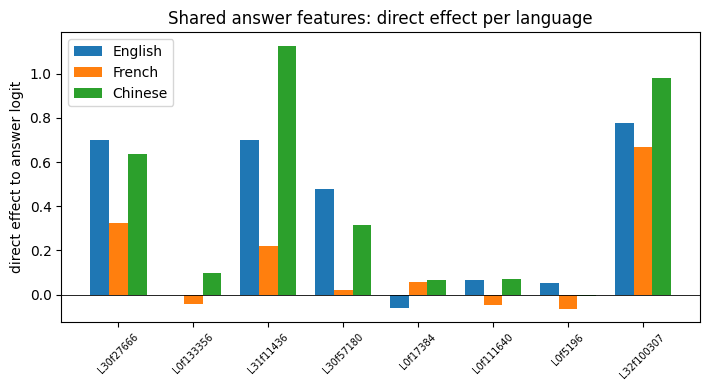

In [8]:
# Shared 'say-big' features = answer features (by influence) appearing in >=2 language graphs.
from collections import Counter
cnt = Counter(); lbl = {}
for lg in LANGS:
    for f in M.answer_features(graphs[lg], top_k=15):
        key=(f['layer'],f['feature_idx']); cnt[key]+=1; lbl[key]=M.feature_label(f)
shared = [k for k,c in cnt.items() if c>=2]
tok_ids = {lg: answers[lg] for lg in LANGS}
print('answer tokens:', {lg: tokenizer.decode([answers[lg]]) for lg in LANGS})
print(f'{len(shared)} answer features shared across >=2 languages:\n')
rows = []
for key in sorted(shared, key=lambda k: -cnt[k]):
    L,i = key; eff = M.direct_logit_effect(model, tc, L, i, tok_ids)
    rows.append((L,i,eff))
    print(f'  [{cnt[key]}L] {lbl[key][:34]:35} ' + '  '.join(f'{lg}={eff[lg]:+.2f}' for lg in LANGS))
if rows:
    em = np.array([[r[2][lg] for lg in LANGS] for r in rows])
    print('\nmean direct effect:', {lg: round(float(em[:,j].mean()),3) for j,lg in enumerate(LANGS)})
    fig, ax = plt.subplots(figsize=(max(6,0.9*len(rows)),4)); x = np.arange(len(rows))
    for j,lg in enumerate(LANGS): ax.bar(x+0.25*j, em[:,j], width=0.25, label=M.LANG_NAME[lg])
    ax.set_xticks(x+0.25); ax.set_xticklabels([f'L{L}f{i}' for L,i,_ in rows], rotation=45, fontsize=7)
    ax.axhline(0, color='k', lw=0.6); ax.set_ylabel('direct effect to answer logit'); ax.legend()
    ax.set_title('Shared answer features: direct effect per language')
    fig.tight_layout(); fig.savefig(OUT/'english_default.png', dpi=130); plt.show()
else:
    print('No features shared across >=2 languages (raise top_k).')

## Summary
Qwen3-4b's antonym task decomposes into operand / operation / language parts, with the paper's
shared-multilingual-core structure partially reproduced. Outcome by experiment:

- **A. Graphs** ✓ — shared say-big features across languages (`L30 f27666` in all three;
  `L31 f11436`, `L32 f100307` in two), language-specific final features alongside.
- **B. Overlap curve** — partial: mid-network peak (layer 18) as the paper predicts, but ends are
  *not* low (no unrelated-prompt baseline control) and `en-zh` is the strongest pair (Qwen-specific).
- **C1. Operand swap (small→hot)** ✓ — cleanest reproduction: top-1 becomes cold / f(roid) / 冷 in
  every language already at ×1, exactly the paper's result.
- **C2. Operation swap (antonym→synonym)** — partial: the synonym direction appears (FR `Pet(it)`,
  ZH `小` at ×3) but **never becomes top-1**; ≥×6 collapses the distribution to junk. The paper
  needed unnaturally strong injections too (crossover ≈4×), but stayed coherent.
- **C3. Language swap** — split: **EN→ZH works** (大 top-1 @ 0.726 at ×3, operation+operand
  preserved); **EN→FR fails** (grand reaches only ~0.09; higher scales degenerate).
- **D. Default language** — **no English privilege on Qwen3-4b**: zh ≥ en ≫ fr (model difference
  vs the paper's Claude-specific claim; see D).

No contradictions with the paper once model differences are acknowledged; the failures (C2 top-1,
C3 EN→FR) mirror the paper's own caveat that required intervention strengths are high relative to
natural activations. Artifacts under `artifacts/multilingual_notebook/`.